In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import cv2
import os
import numpy as np
import random
import time
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchvision import transforms
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
import matplotlib.pyplot as plt

In [13]:
# ==========================================
# 1. CONFIGURATION ET CONSTANTES
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SCREEN_W, SCREEN_H = 1272, 712
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 3

# Ratios de budget conformes au guideline (1%, 2%, 5%, 10%, 20%, 50%)
BUDGET_RATIOS = [5, 10, 20, 50]

# Nombre de runs pour moyenne et intervalles de confiance
N_RUNS = 1  # Augmenter à 5 pour le rapport final

# Protocole AL (réponses aux 3 questions du guideline)
KEEP_DOMAIN_A = False       # Q1: Garder Domaine A en plus du subset B ?
INCREMENTAL_SELECTION = True  # Q2: Sélection incrémentale (cumulative) ?
RETRAIN_FROM_SCRATCH = False   # Q3: Réentraînement from scratch à chaque cycle ?

## Protocole Active Learning (réponses au guideline)

1. **Q1 – Garder les données du Domaine A ?**  
   Oui (`KEEP_DOMAIN_A = True`). Le modèle est entraîné sur Domaine A (si disponible) + le subset labellisé du Domaine B à chaque cycle.

2. **Q2 – Sélection incrémentale ?**  
   Oui (`INCREMENTAL_SELECTION = True`). On conserve les exemples labellisés des cycles précédents et on ajoute progressivement de nouveaux exemples selon le budget.

3. **Q3 – Réentraînement from scratch ?**  
   Oui (`RETRAIN_FROM_SCRATCH = True`). À chaque cycle, on réinitialise le modèle et on l’entraîne sur l’ensemble des données labellisées disponibles.

In [14]:
class GazeNet(nn.Module):
    def __init__(self):
        super(GazeNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 112x112
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 56x56
            nn.MaxPool2d(2), # 28x28
            nn.MaxPool2d(2), # 14x14
            nn.Dropout(0.2)
        )
        
        self.fc = nn.Sequential(
            nn.Linear(32 * 14 * 14, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [15]:
# ==========================================
# 3. DATASET ET PRÉPARATION
# ==========================================
class EyeTrackingDataset(Dataset):
    def __init__(self, csv_file, img_dir, img_size=(224,224), transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.img_size = img_size
        self.transform = transform

        # filtrer les lignes où l'image existe et est valide
        valid_indices = []
        for idx, row in self.df.iterrows():
            fid = int(row['frame_id'])
            img_path = os.path.join(img_dir, f"SC1_{fid:04d}.png")
            if os.path.exists(img_path):
                img = cv2.imread(img_path)
                if img is not None and len(img.shape) == 3 and img.shape[0] > 0 and img.shape[1] > 0:
                    valid_indices.append(idx)
        self.df = self.df.iloc[valid_indices].reset_index(drop=True)

        # créer mapping frame_id -> image path
        self.img_paths = [os.path.join(img_dir, f"SC1_{int(fid):04d}.png") 
                          for fid in self.df['frame_id']]

        # extraire les coordonnées
        self.coords = self.df[['x','y']].values.astype(np.float32)

        # Calculer les maxima pour normalisation
        self.max_x = 1272 #np.max(self.coords[:, 0])
        self.max_y = 712 #np.max(self.coords[:, 1])

        # Normaliser toutes les coordonnées
        self.coords[:, 0] /= self.max_x
        self.coords[:, 1] /= self.max_y
        

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = cv2.imread(img_path)
        if img.ndim == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        elif img.shape[2] == 1:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # resize
        img = cv2.resize(img, self.img_size)

        # coordonnées déjà normalisées
        x, y = self.coords[idx]
        label = torch.tensor([x, abs(y)], dtype=torch.float32)

        # transform PyTorch (ToTensor + normalisation)
        if self.transform:
            img = self.transform(img)
        else:
            # default transform
            img = transforms.ToTensor()(img)
            img = transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])(img)

        return img, label

In [16]:
def select_samples(model, unlabelled_loader, strategy, n_to_select, labelled_loader=None):
    model.eval()
    
    # --- OPTIMISATION MISE À JOUR (Évite l'erreur n_samples < n_clusters) ---
    all_indices = list(range(len(unlabelled_loader.dataset)))
    
    # On s'assure que le subset est au moins 1.5x plus grand que n_to_select
    # pour que KMeans puisse fonctionner, tout en gardant un minimum de 500.
    subset_size = max(int(n_to_select * 1.5), 500) 
    subset_size = min(subset_size, len(all_indices)) # Sécurité : ne pas dépasser le pool

    if len(all_indices) > subset_size:
        subset_indices = random.sample(all_indices, subset_size)
        subset_ds = Subset(unlabelled_loader.dataset, subset_indices)
        eval_loader = DataLoader(subset_ds, batch_size=32, shuffle=False)
    else:
        subset_indices = all_indices
        eval_loader = unlabelled_loader

    if strategy == 'Random':
        return random.sample(all_indices, n_to_select)

    scores_or_features = []
    N_MC = 3 # Nombre de passes Dropout réduit pour la vitesse

    with torch.no_grad():
        for imgs, _ in eval_loader:
            imgs = imgs.to(DEVICE)
            
            if strategy == 'Uncertainty':
                model.train() 
                preds = torch.stack([model(imgs) for _ in range(N_MC)])
                uncertainty = preds.var(dim=0).mean(dim=1).cpu().numpy()
                scores_or_features.extend(uncertainty)
                
            elif strategy in ('Diversity', 'Uncertainty_Outlier'):
                feat = model.features(imgs).view(imgs.size(0), -1)
                scores_or_features.extend(feat.cpu().numpy())
                
            elif strategy == 'Mixed_UncDiv':
                model.train()
                preds = torch.stack([model(imgs) for _ in range(N_MC)])
                unc = preds.var(dim=0).mean(dim=1).cpu().numpy()
                feat = model.features(imgs).view(imgs.size(0), -1).cpu().numpy()
                for i in range(len(unc)):
                    scores_or_features.append((unc[i], feat[i]))

    # --- SÉLECTION FINALE ---
    if strategy == 'Uncertainty':
        local_idx = np.argsort(scores_or_features)[-n_to_select:]
        return [subset_indices[i] for i in local_idx]

    if strategy == 'Diversity':
        # n_init=1 pour la rapidité CPU
        kmeans = KMeans(n_clusters=n_to_select, n_init=1, random_state=42).fit(scores_or_features)
        closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, scores_or_features)
        return [subset_indices[i] for i in closest]

    if strategy == 'Mixed_UncDiv':
        unc_scores = np.array([x[0] for x in scores_or_features])
        all_feat = np.array([x[1] for x in scores_or_features])
        top_k = min(2 * n_to_select, len(unc_scores))
        top_local_idx = np.argsort(unc_scores)[-top_k:]
        top_features = all_feat[top_local_idx]
        kmeans = KMeans(n_clusters=n_to_select, n_init=1).fit(top_features)
        closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, top_features)
        return [subset_indices[top_local_idx[i]] for i in closest]

    return random.sample(all_indices, n_to_select)

In [17]:
# ==========================================
# 5. BOUCLE D'ACTIVE LEARNING (RATIOS 1,2,5,10,20,50%, MULTI-RUNS, TIME)
# ==========================================
def train_model(model, train_loader, epochs=EPOCHS):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    model.train()
    for _ in range(epochs):
        for imgs, targets in train_loader:
            imgs, targets = imgs.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), targets)
            loss.backward()
            optimizer.step()

def evaluate_mae(model, loader):
    model.eval()
    mae_sum = 0
    with torch.no_grad():
        for imgs, targets in loader:
            imgs, targets = imgs.to(DEVICE), targets.to(DEVICE)
            mae_sum += torch.abs(model(imgs) - targets).mean().item()
    return mae_sum / len(loader) if len(loader) > 0 else 0

def run_al_experiment(dataset_pool_B, test_loader, strategy, dataset_A=None, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)
        random.seed(seed)
    
    pool_size = len(dataset_pool_B)
    indices_pool = list(range(pool_size))
    results_mae = []
    
    # --- MODIFICATION : On initialise le modèle UNE SEULE FOIS ici ---
    model = GazeNet().to(DEVICE)
    labelled_idx = []
    
    t_start = time.time()
    
    for ratio_idx, ratio in enumerate(BUDGET_RATIOS):
        n_labeled = max(10, int(pool_size * ratio / 100))
        n_to_add = n_labeled - len(labelled_idx)
        
        if n_to_add > 0:
            unlabelled_idx = list(set(indices_pool) - set(labelled_idx))
            unlabelled_loader = DataLoader(Subset(dataset_pool_B, unlabelled_idx), batch_size=BATCH_SIZE)
            
            # Sélection des nouveaux points
            new_rel = select_samples(model, unlabelled_loader, strategy, n_to_add)
            new_global = [unlabelled_idx[i] for i in new_rel]
            labelled_idx.extend(new_global)
        
        # Préparation de l'entraînement
        train_dataset = Subset(dataset_pool_B, labelled_idx)
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        
        # Entraînement incrémental (on ne reset pas le modèle)
        train_model(model, train_loader, epochs=EPOCHS)
        
        mae = evaluate_mae(model, test_loader)
        results_mae.append(mae)
        print(f"  Ratio {ratio}% fini - MAE: {mae:.4f}")
    
    elapsed = time.time() - t_start
    return results_mae, elapsed

In [18]:
# ==========================================
# 6. MAIN - CHARGEMENT DES DONNÉES
# ==========================================
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "data")

# Chemins Domaine B (obligatoire)
csv_path_B = os.path.join(DATA_DIR, "domaineb", "coords_SC1.csv")
img_dir_B = os.path.join(DATA_DIR, "domaineb", "framesSC1")

# Chemins Domaine A (optionnel - pour baseline et KEEP_DOMAIN_A)
csv_path_A = os.path.join(DATA_DIR, "domainea", "coords_SC1.csv")
img_dir_A = os.path.join(DATA_DIR, "domainea", "framesSC1")

transform = transforms.Compose([
    transforms.ToPILImage(), transforms.Resize(IMG_SIZE),
    transforms.ToTensor(), transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

full_dataset_B = EyeTrackingDataset(csv_path_B, img_dir_B, transform=transform)

# Split 80% Pool AL / 20% Test (guideline point 3)
train_size = int(0.8 * len(full_dataset_B))
test_size = len(full_dataset_B) - train_size
dataset_pool_B, dataset_test_B = random_split(full_dataset_B, [train_size, test_size])
test_loader = DataLoader(dataset_test_B, batch_size=BATCH_SIZE)

# Domaine A optionnel (baseline training set)
dataset_A = None
if os.path.exists(csv_path_A) and os.path.exists(img_dir_A):
    dataset_A = EyeTrackingDataset(csv_path_A, img_dir_A, transform=transform)
    print("Domaine A chargé.")
else:
    print("Domaine A non trouvé (optionnel). KEEP_DOMAIN_A ignoré.")

# Tableau des splits (guideline point 3)
print("\n=== TABLEAU DES SPLITS ===")
print(f"{'Sous-ensemble':<25} {'Nb échantillons':<18} {'%'}")
print("-"*55)
print(f"{'Baseline (Domaine A)':<25} {len(dataset_A) if dataset_A else 0:<18} {(100*len(dataset_A)/len(full_dataset_B) if dataset_A else 0):.1f}%")
print(f"{'Pool AL (Domaine B)':<25} {len(dataset_pool_B):<18} {100*len(dataset_pool_B)/len(full_dataset_B):.1f}%")
print(f"{'Test (Domaine B)':<25} {len(dataset_test_B):<18} {100*len(dataset_test_B)/len(full_dataset_B):.1f}%")
print("-"*55)
print(f"{'TOTAL':<25} {len(full_dataset_B):<18} 100%")

n_params = sum(p.numel() for p in GazeNet().parameters())
print(f"\nParamètres du modèle : {n_params:,}")

Domaine A non trouvé (optionnel). KEEP_DOMAIN_A ignoré.

=== TABLEAU DES SPLITS ===
Sous-ensemble             Nb échantillons    %
-------------------------------------------------------
Baseline (Domaine A)      0                  0.0%
Pool AL (Domaine B)       5719               80.0%
Test (Domaine B)          1430               20.0%
-------------------------------------------------------
TOTAL                     7149               100%

Paramètres du modèle : 808,290


In [19]:
# ==========================================
# 7. BASELINE (sans Active Learning) - guideline point 3
# ==========================================
print("=== PERFORMANCE BASELINE (sans AL) ===")
t0 = time.time()
if dataset_A is not None:
    baseline_train = DataLoader(dataset_A, batch_size=BATCH_SIZE, shuffle=True)
    model_baseline = GazeNet().to(DEVICE)
    train_model(model_baseline, baseline_train)
    mae_A = evaluate_mae(model_baseline, test_loader)
    t_baseline = time.time() - t0
    print(f"Domaine A seulement -> MAE sur Test B: {mae_A:.4f} | Temps: {t_baseline:.1f}s")
else:
    # Fallback: modèle non entraîné ou pool minimal
    model_baseline = GazeNet().to(DEVICE)
    mae_baseline_naive = evaluate_mae(model_baseline, test_loader)
    print(f"Pas de Domaine A. MAE modèle non entraîné: {mae_baseline_naive:.4f}")

=== PERFORMANCE BASELINE (sans AL) ===
Pas de Domaine A. MAE modèle non entraîné: 0.6221


In [20]:
# ==========================================
# 8. LANCEMENT - Multiples runs (moyenne + IC)
# ==========================================
STRATEGIES = ['Random', 'Uncertainty', 'Uncertainty_Outlier', 'Diversity', 'Diversity_Coreset', 'Mixed_UncDiv', 'Mixed_DivUnc']

all_results = {}  # strategy -> {"mae_mean": [], "mae_std": [], "mae_ci": [], "time_mean": float}
print(">>> Lancement des stratégies (N_RUNS =", N_RUNS, ")")
print("Ratios budget:", BUDGET_RATIOS, "%")
 
for strategy in STRATEGIES:
    print(f"\n--- Stratégie: {strategy} ---")
    runs_mae = []
    runs_time = []
    for run in range(N_RUNS):
        mae_list, elapsed = run_al_experiment(dataset_pool_B, test_loader, strategy, dataset_A=dataset_A, seed=42+run)
        runs_mae.append(mae_list)
        runs_time.append(elapsed)
    
    mae_arr = np.array(runs_mae)
    mean_mae = np.mean(mae_arr, axis=0)
    std_mae = np.std(mae_arr, axis=0)
    ci_95 = 1.96 * std_mae / np.sqrt(N_RUNS)  # IC 95% (approximation normale)
    
    all_results[strategy] = {
        "mae_mean": mean_mae.tolist(),
        "mae_std": std_mae.tolist(),
        "mae_ci": ci_95.tolist(),
        "time_mean": np.mean(runs_time),
        "time_std": np.std(runs_time)
    }
    print(f"MAE (mean±std): {mean_mae[-1]:.4f} ± {std_mae[-1]:.4f} | Temps: {np.mean(runs_time):.1f}s")

>>> Lancement des stratégies (N_RUNS = 1 )
Ratios budget: [5, 10, 20, 50] %

--- Stratégie: Random ---
  Ratio 5% fini - MAE: 0.3233
  Ratio 10% fini - MAE: 0.3004
  Ratio 20% fini - MAE: 0.2555
  Ratio 50% fini - MAE: 0.1809
MAE (mean±std): 0.1809 ± 0.0000 | Temps: 545.3s

--- Stratégie: Uncertainty ---
  Ratio 5% fini - MAE: 0.3150
  Ratio 10% fini - MAE: 0.2996
  Ratio 20% fini - MAE: 0.2602
  Ratio 50% fini - MAE: 0.1871
MAE (mean±std): 0.1871 ± 0.0000 | Temps: 828.8s

--- Stratégie: Uncertainty_Outlier ---
  Ratio 5% fini - MAE: 0.3164
  Ratio 10% fini - MAE: 0.3089
  Ratio 20% fini - MAE: 0.2754
  Ratio 50% fini - MAE: 0.1897
MAE (mean±std): 0.1897 ± 0.0000 | Temps: 724.0s

--- Stratégie: Diversity ---
  Ratio 5% fini - MAE: 0.3151
  Ratio 10% fini - MAE: 0.3050
  Ratio 20% fini - MAE: 0.2636
  Ratio 50% fini - MAE: 0.1848
MAE (mean±std): 0.1848 ± 0.0000 | Temps: 672.2s

--- Stratégie: Diversity_Coreset ---
  Ratio 5% fini - MAE: 0.3164
  Ratio 10% fini - MAE: 0.3089
  Ratio 20% 

In [21]:
# ==========================================
# 9. TABLEAU RÉCAPITULATIF ET COURBES
# ==========================================
print("\n=== TABLEAU MAE par ratio (moyenne ± IC 95%) ===")
print(f"{'Stratégie':<20}", end="")
for r in BUDGET_RATIOS: 
    print(f" | {r}%{'':>6}", end="")
print()
print("-" * (20 + 11 * len(BUDGET_RATIOS)))
for strat, data in all_results.items():
    row = f"{strat:<20}"
    for m, c in zip(data["mae_mean"], data["mae_ci"]):
        row += f" | {m:.4f}±{c:.4f}"
    print(row)

print("\n=== TEMPS DE CALCUL (secondes) ===")
for strat, data in all_results.items():
    print(f"  {strat}: {data['time_mean']:.1f} ± {data['time_std']:.1f} s")


=== TABLEAU MAE par ratio (moyenne ± IC 95%) ===
Stratégie            | 5%       | 10%       | 20%       | 50%      
----------------------------------------------------------------
Random               | 0.3233±0.0000 | 0.3004±0.0000 | 0.2555±0.0000 | 0.1809±0.0000
Uncertainty          | 0.3150±0.0000 | 0.2996±0.0000 | 0.2602±0.0000 | 0.1871±0.0000
Uncertainty_Outlier  | 0.3164±0.0000 | 0.3089±0.0000 | 0.2754±0.0000 | 0.1897±0.0000
Diversity            | 0.3151±0.0000 | 0.3050±0.0000 | 0.2636±0.0000 | 0.1848±0.0000
Diversity_Coreset    | 0.3164±0.0000 | 0.3089±0.0000 | 0.2754±0.0000 | 0.1897±0.0000
Mixed_UncDiv         | 0.3167±0.0000 | 0.3032±0.0000 | 0.2546±0.0000 | 0.2040±0.0000
Mixed_DivUnc         | 0.3164±0.0000 | 0.3089±0.0000 | 0.2754±0.0000 | 0.1897±0.0000

=== TEMPS DE CALCUL (secondes) ===
  Random: 545.3 ± 0.0 s
  Uncertainty: 828.8 ± 0.0 s
  Uncertainty_Outlier: 724.0 ± 0.0 s
  Diversity: 672.2 ± 0.0 s
  Diversity_Coreset: 570.7 ± 0.0 s
  Mixed_UncDiv: 987.0 ± 0.0 s
  Mi

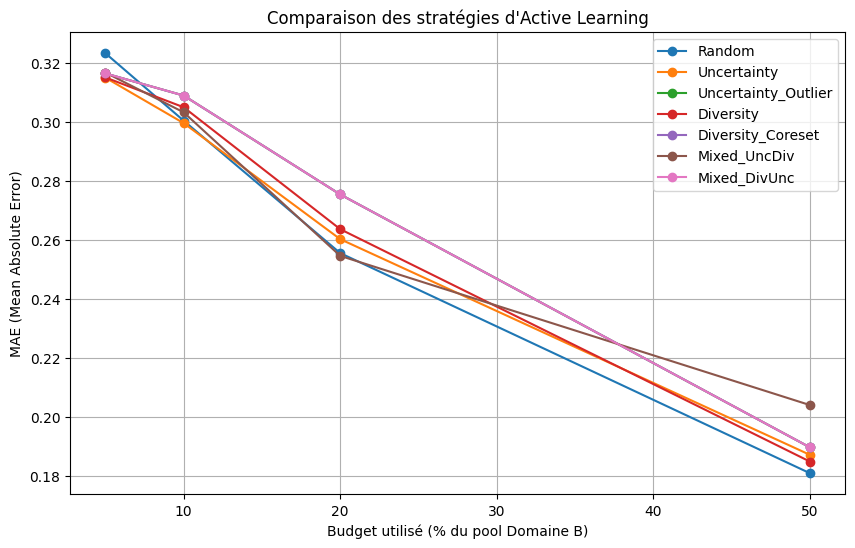

In [22]:
# Courbe Finale (moyenne ± IC 95%)
plt.figure(figsize=(10, 6))

for s, h in all_results.items():
    mae = np.array(h["mae_mean"])
    ci = np.array(h["mae_ci"])
    plt.plot(BUDGET_RATIOS, mae, label=s, marker='o')
    plt.fill_between(BUDGET_RATIOS, mae - ci, mae + ci, alpha=0.2)

plt.xlabel("Budget utilisé (% du pool Domaine B)")
plt.ylabel("MAE (Mean Absolute Error)")
plt.title("Comparaison des stratégies d'Active Learning")
plt.legend()
plt.grid(True)

plt.show()